# Task 1: Image Enhancement

### a) Visualize the initial image and the corresponding histogram.


[[[180 181 176]
  [191 192 187]
  [205 206 201]
  ...
  [164 164 164]
  [164 164 164]
  [164 164 164]]

 [[180 181 176]
  [192 193 188]
  [205 206 201]
  ...
  [164 164 164]
  [164 164 164]
  [164 164 164]]

 [[176 177 172]
  [184 185 180]
  [196 197 192]
  ...
  [164 164 164]
  [164 164 164]
  [164 164 164]]

 ...

 [[167 168 170]
  [169 170 172]
  [169 170 172]
  ...
  [170 170 170]
  [169 169 169]
  [171 171 171]]

 [[167 168 170]
  [169 170 172]
  [170 171 173]
  ...
  [173 173 173]
  [171 171 171]
  [173 173 173]]

 [[167 168 170]
  [169 170 172]
  [170 171 173]
  ...
  [173 173 173]
  [171 171 171]
  [173 173 173]]]


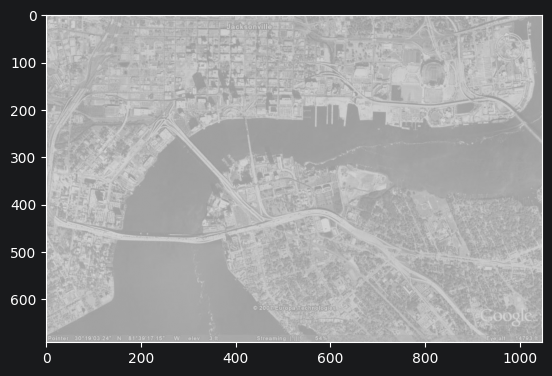

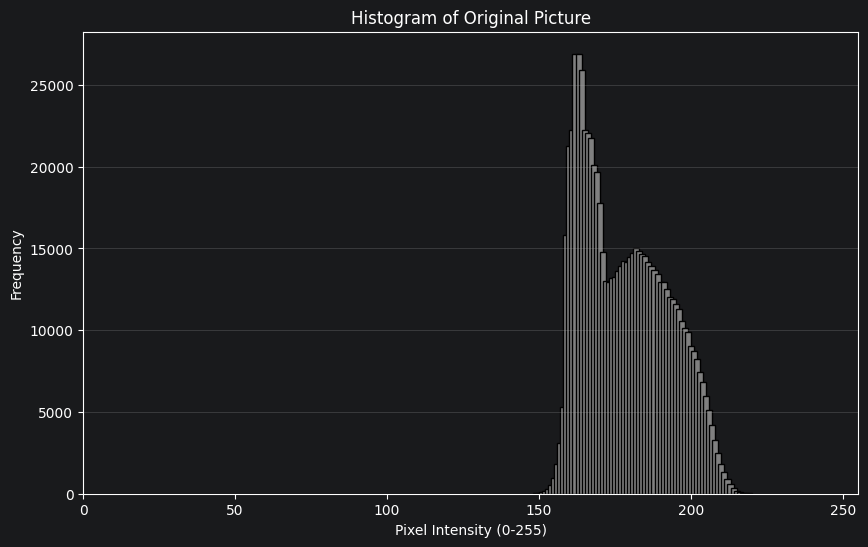

In [53]:
from utils import *
from PIL import Image
import matplotlib.pyplot as plt
plt.close('all')

img = Image.open("../input_sat_image.jpg")
img_array = np.array(img)
print(img_array)
greyscale = rgb2gray(img_array)
plt.imshow(greyscale, cmap='gray', vmin=0, vmax=255)

def draw_histogram(image_array, title='Histogram'):
    hist, bin_edges = np.histogram(image_array.flatten(), bins=256, range=(0, 256))
    plt.figure(figsize=(10, 6))
    plt.bar(bin_edges[:-1], hist, width=2, color='gray', edgecolor='black')
    plt.xlim(0, 255)
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

draw_histogram(greyscale,'Histogram of Original Picture')




### b) Describe the characteristics of the histogram.
The histogram of the greyscale image shows the distribution of pixel intensities. We can see that the pixel intensities are clustered around the higher end of the intensity range, which indicates that the image is relatively bright. Since the values are close to each other and are clustered, it indicates that the image has low contrast, as there isn't much variation in pixel intensity.

### c) Enhance the image using contrast stretching.

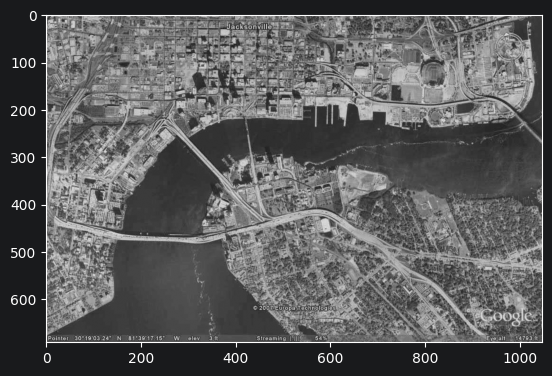

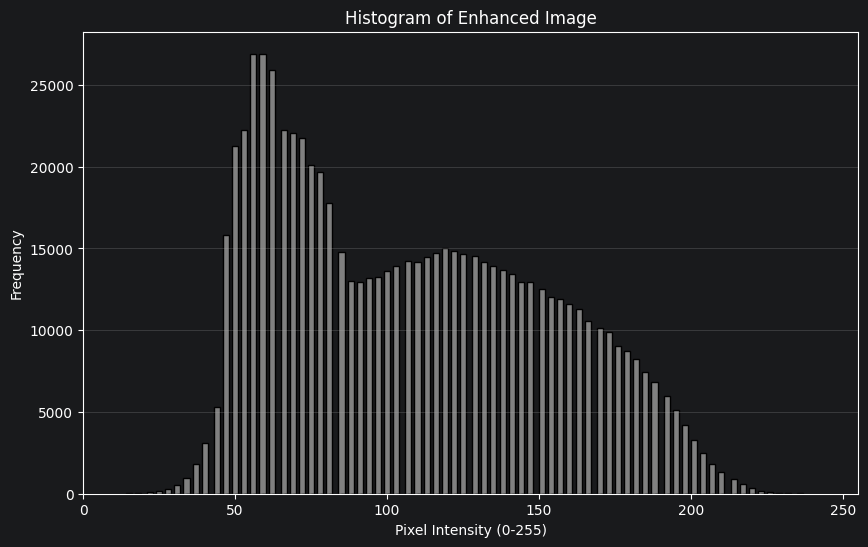

In [54]:
def contrast_stretching(image):
    min_pixel = np.min(image)
    max_pixel = np.max(image)
    stretched_image = (image - min_pixel) * (255 / (max_pixel - min_pixel))
    return stretched_image.astype(np.uint8)

enhanced_image = contrast_stretching(greyscale)
plt.imshow(enhanced_image, cmap='gray', vmin=0, vmax=255)
draw_histogram(enhanced_image, 'Histogram of Enhanced Image')

### d) Shortly describe the differences to the initial histogram.
The pixel values are now more spread across the entire intensity range, which indicates that the contrast of the image has been improved. Along with the brighter pixels, there are now more darker pixels as well, which adds more contrast.

# Task 2 - Binarization
### Write a function for thresholding the enhanced image of Task 1)

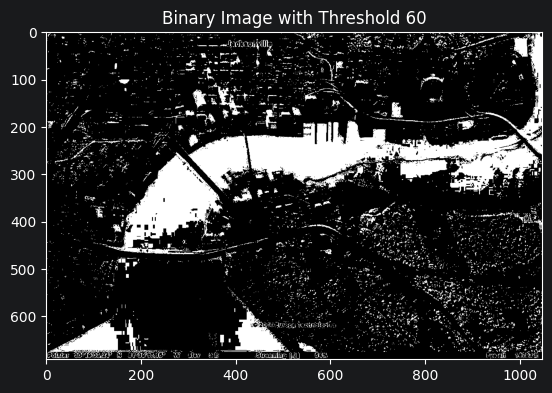

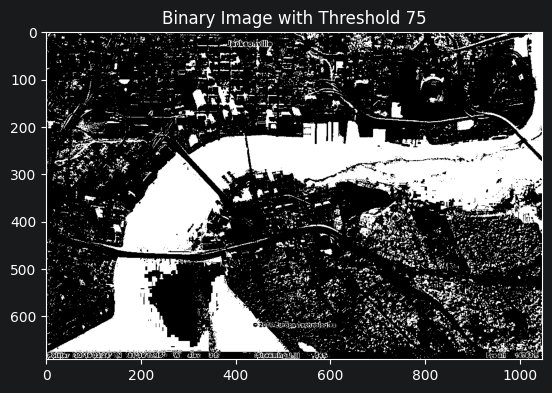

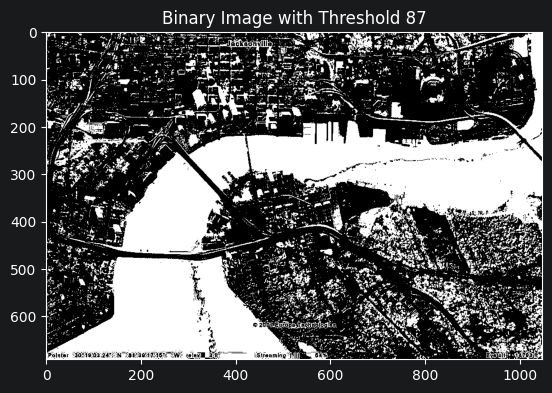

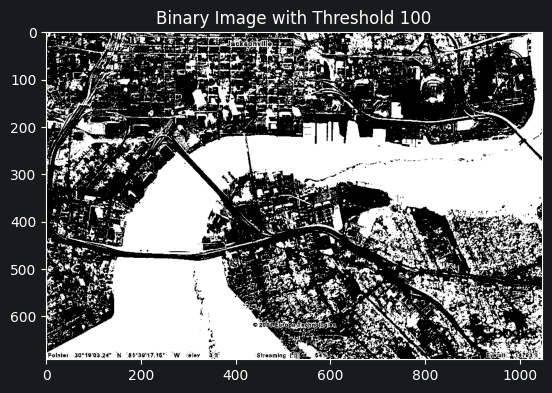

In [55]:
def thresholding(image, threshold):
    binary_image = (image < threshold).astype(np.uint8)
    return binary_image

for threshold in [60, 75, 87, 100]:
    binary_image = thresholding(enhanced_image, threshold)
    plt.imshow(binary_image, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Binary Image with Threshold {threshold}')
    plt.show()

### c) Test a number of different threshold values and describe the effects. Did you experience any difficulties while searching for an appropriate threshold value?
When looking at the histogram of the enhanced image, it becomes relatively easy to find an approximate value for a suited threshold. Around the 75 intensity mark, one can see a separation between the many dark pixels and the following brighter pixels, since before that value, there is a big spike of dark pixels. When testing that value, one can see in the image, that quite a big part of the lower water surface is still considered background, which can be improved by correcting the value upwards a little, e.g. to 87, which produces a pretty good binary mask which singles out the water surfaces. When increasing the value further, e.g. to 100, the mask begins to show more of the land mass as foreground as well, which is not desired. Since some streets and buildings in the original picture are similarly dark as the water surface, it will be hard to separate them, which in turn makes it hard to find an ideal threshold value.

# Task 3 - Morphological Operators
### Write a function for morphological filtering of the binary mask obtained in Task 2)

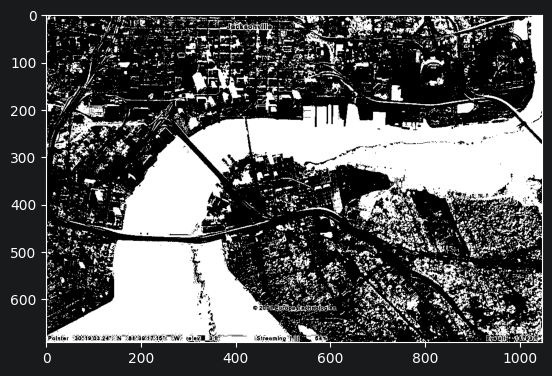

[0 1]


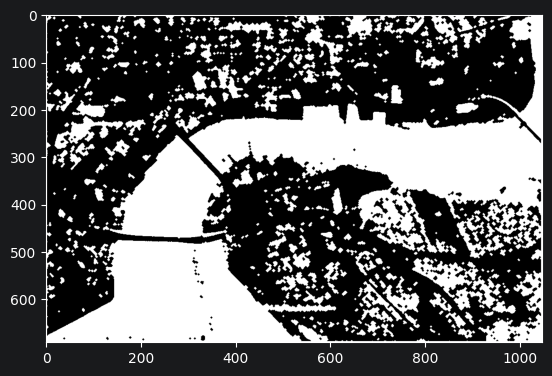

In [56]:
def morphological_filtering(mask, struct_el):
    # flip bw
    flipped = 1 - mask
    fmask_open = imopen(flipped, struct_el)
    fmask_closed = imclose(fmask_open, struct_el)
    # flip back
    return 1 - fmask_closed.astype(np.uint8)

binary_mask_87 = thresholding(np.copy(enhanced_image), 87)
plt.imshow(binary_mask_87, cmap='gray', vmin=0, vmax=1)
plt.show()
print(np.unique(binary_mask_87))

#struct_el = np.array([
#    [0,1,0],
#    [1,1,1],
#    [0,1,0]
#])

struct_el = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
])


filtered_mask = morphological_filtering(binary_mask_87, struct_el)
plt.imshow(filtered_mask, cmap='gray', vmin=0, vmax=1)
plt.show()


### b) Visualize an overlay of the contrast enhanced image and the final filtered mask.

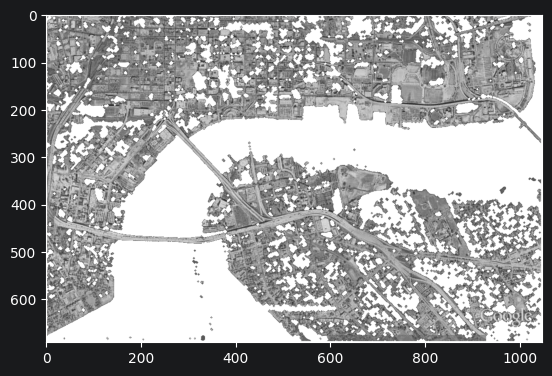

In [57]:
def add_overlay(img, mask):
    x_im, y_im = img.shape
    x_mk, y_mk = mask.shape
    if x_im != x_mk or y_im != y_mk:
        print("Resolution mismatch, will not add mask")
        return
    out = np.copy(img)
    for i in range(x_im):
        for j in range(y_im):
            if mask[i,j] == 1:
                out[i,j] = 255
    return out


overlay = add_overlay(enhanced_image, filtered_mask)
plt.imshow(overlay, cmap='gray', vmin=0, vmax=255)
plt.show()

### c) Write a main function which sequentially executes the functions from Task 1 to 3.

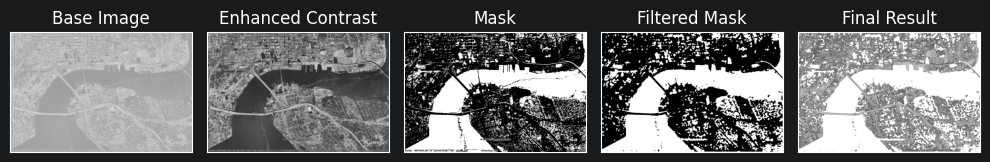

In [58]:
def main():
    # default values
    img_orig = Image.open("../input_sat_image.jpg")
    threshold = 87
    structural_element = np.array([
        [0,0,1,0,0], 
        [0,1,1,1,0], 
        [1,1,1,1,1],
        [0,1,1,1,0], 
        [0,0,1,0,0]
    ])

    # functions
    img_arr = np.array(img_orig)
    img_grey = rgb2gray(img_arr)
    img_enh = contrast_stretching(np.copy(img_grey))
    mask = thresholding(np.copy(img_enh), threshold)
    mask_enh = morphological_filtering(mask, structural_element)
    final = add_overlay(img_enh, mask_enh)

    # drawing	
    fig, axes = plt.subplots(1, 5, figsize=(10, 5))
    
    axes[0].imshow(img_grey, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Base Image')
    axes[1].imshow(img_enh, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('Enhanced Contrast')
    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Mask')
    axes[3].imshow(mask_enh, cmap='gray')
    axes[3].set_title('Filtered Mask')
    axes[4].imshow(final, cmap='gray', vmin=0, vmax=255)
    axes[4].set_title('Final Result')
    
    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

### d) Are the results satisfactory? What are the limitations of this approach for foreground-background separation?

The result shows a considerable improvement to the original image.

While we managed to highlight almost all water surfaces, we also have a rather high area that is not water surface being falsely labeled as such.

We might be able to optimize this further by doing multiple passes and fine-tuning the mask via structural elements as well as the threshold, this makes it not only more time-consuming to compute the result, but also much more image-specific.

It would also break if we had something that looked similar to a water surface like a soccer field because it can look similar enough.

### e) Test your program with a different low-contrast input image of your choice. Do you notice a significant difference with respect to quality of the results for the different input images?


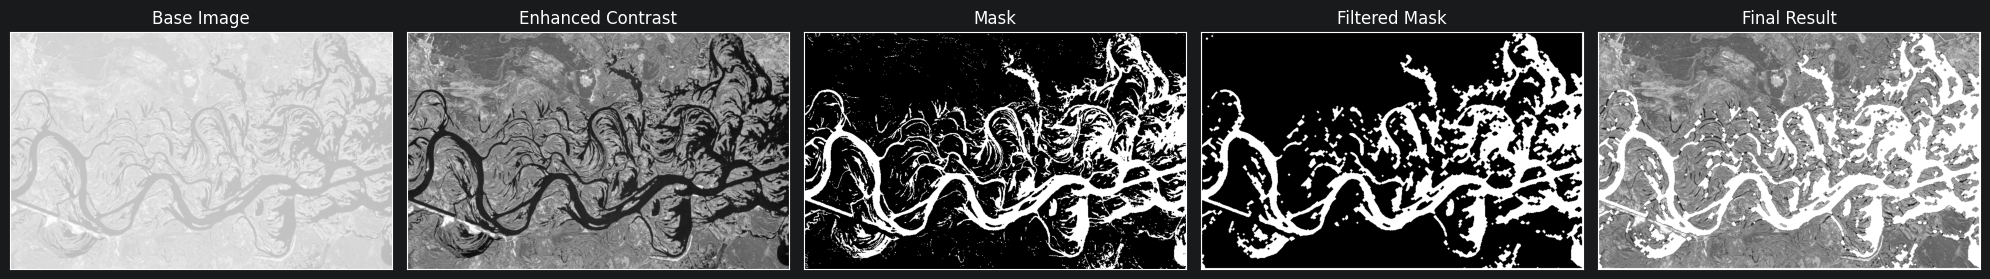

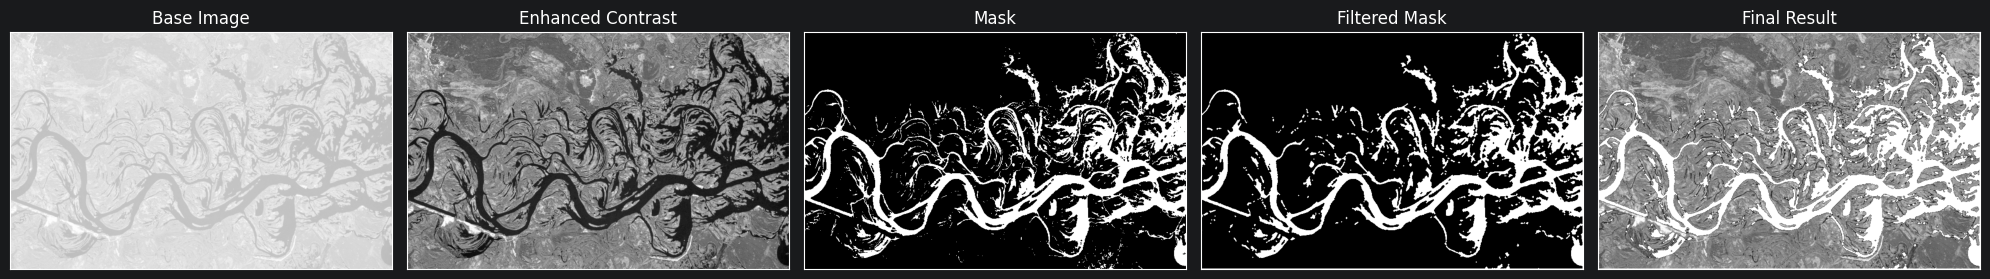

In [65]:
def compute_functions_and_plot(img_orig, structural_element, threshold):
        # functions
        img_arr = np.array(img_orig)
        img_grey = rgb2gray(img_arr)
        img_enh = contrast_stretching(np.copy(img_grey))
        mask = thresholding(np.copy(img_enh), threshold)
        mask_enh = morphological_filtering(mask, structural_element)
        final = add_overlay(img_enh, mask_enh)

        # drawing
        fig, axes = plt.subplots(1, 5, figsize=(20, 8))

        axes[0].imshow(img_grey, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title('Base Image')
        axes[1].imshow(img_enh, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title('Enhanced Contrast')
        axes[2].imshow(mask, cmap='gray')
        axes[2].set_title('Mask')
        axes[3].imshow(mask_enh, cmap='gray')
        axes[3].set_title('Filtered Mask')
        axes[4].imshow(final, cmap='gray', vmin=0, vmax=255)
        axes[4].set_title('Final Result')

        for ax in axes.flat:
            ax.set_xticks([])
            ax.set_yticks([])
        plt.tight_layout()
        plt.show()

def main():
    # default values
    img_orig = Image.open("../Dnieper-river-low-contrast.png")
    img_orig = img_orig.convert('RGB')

    threshold_1 = 87
    structural_element_1 = np.array([
        [0,0,1,0,0],
        [0,1,1,1,0],
        [1,1,1,1,1],
        [0,1,1,1,0],
        [0,0,1,0,0]
    ])

    threshold_2 = 60

    structural_element_2 = np.array([
        [0,1,0],
        [1,1,1],
        [0,1,0]
    ])

    compute_functions_and_plot(img_orig, structural_element_1, threshold_1)
    compute_functions_and_plot(img_orig, structural_element_2, threshold_2)

if __name__ == "__main__":
    main()

As a further test image the image from the Dnieper River was chosen (https://www.geoawesome.com/wp-content/uploads/2022/03/Dnieper-river.png; Accessed: 06.05.2026) and then manually desaturated with the Image editing software Gimp. Both images are attached in the src folder.

When looking at the parameters that were chosen for the `input_sat_image.jpg` it is visible that the higher threshold picks up many artifacts that are actually not water. Also, the structuring element that is bigger increases the finer structures of the water and adds in water areas where there is no water. Adding to that some fine areas of water are excluded.

When changing the threshold to a smaller value and the structuring element to a smaller matrix most water areas are picked up quite nicely, but the opening and closing sequence gets rid of some finer water structures.

Quality wise both the original and the adapted parameters are not ideal same as with the `input_sat_image.jpg`.